# RV Prior Estimation via Cross-Correlation

Cross-correlate DH Tau B combined spectrum against Sonora Diamondback cloud-free templates
(log g=3.7, C/O=0.54, [Fe/H]=0.5, vsini=5.7 km/s) over a Teff grid {2000, 2100, 2200, 2300, 2400} K
to determine the RV prior for the subsequent retrieval.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate
from astropy.io import fits

In [2]:
# ---- Paths ----
workpath = '/data2/peng'
night    = '2022-12-31'

# ---- Load flux-calibrated combined spectrum ----
extracted_spectra_combined = np.load(f'{workpath}/{night}/extracted_spectra_combined_flux_cal.npy')
# shape: (nDet=3, nOrder=5, nPix=2048)

# ---- Load wavelength grid ----
wave_hdu  = fits.open(f'{workpath}/{night}/cal/WLEN_K2166_V_DH_Tau_A+B_center.fits')
wave_data = np.array(wave_hdu[1].data)[:, 0:5, :]   # (3, 5, 2048) in nm

nDet, nOrder, nPix = extracted_spectra_combined.shape
cube_combined      = extracted_spectra_combined[:, :, np.newaxis, :]  # (3, 5, 1, 2048)

print(f'Obs spectrum shape : {extracted_spectra_combined.shape}')
print(f'Obs cube shape     : {cube_combined.shape}')
print(f'Wave grid shape    : {wave_data.shape}')
print(f'Wave range         : {wave_data.min():.1f} – {wave_data.max():.1f} nm')

Obs spectrum shape : (3, 5, 2048)
Obs cube shape     : (3, 5, 1, 2048)
Wave grid shape    : (3, 5, 2048)
Wave range         : 2063.7 – 2472.3 nm


In [3]:
# ============================================================
# Cross-Correlator class  (adapted from cooking_combine_spectra.ipynb)
# ============================================================

class processor_cross_correlation:
    def __init__(self, wMod, fMod, wlen, cube, nOrder, n_spatial, nDet):
        """
        wMod, fMod : 1-D model wavelength [nm] and flux
        wlen       : observed wavelength grid, shape (nDet, nOrder, nPix) [nm]
        cube       : observed cube, shape (nDet, nOrder, n_spatial, nPix)
        """
        self.wMod      = wMod
        self.fMod      = fMod
        self.wlen      = wlen
        self.cube      = cube
        self.n_spatial = n_spatial
        self.nOrder    = nOrder
        self.nDet      = nDet

    def xcorr(self, f, g):
        """Normalized cross-correlation between two 1-D arrays."""
        f  = np.asarray(f, dtype=float)
        g  = np.asarray(g, dtype=float)
        nx = len(f)
        if nx == 0:
            return np.nan
        I         = np.ones(nx)
        f_ms      = f - np.dot(f, I) / nx
        g_ms      = g - np.dot(g, I) / nx
        R         = np.dot(f_ms, g_ms) / nx
        varf      = np.dot(f_ms, f_ms) / nx
        varg      = np.dot(g_ms, g_ms) / nx
        denom     = np.sqrt(varf * varg)
        if denom == 0 or np.isnan(denom):
            return np.nan
        return R / denom

    def get_cc_grid(self, rvlag, ncc):
        """Compute CCF cube with shape (nDet, nOrder, n_spatial, ncc)."""
        ccf         = np.zeros((self.nDet, self.nOrder, self.n_spatial, ncc))
        coef_spline = interpolate.splrep(self.wMod, self.fMod, s=0.0)

        for irv, rv in enumerate(rvlag):
            beta   = rv / 2.998e5
            wShift = self.wlen * np.sqrt((1.0 - beta) / (1.0 + beta))
            intMod = interpolate.splev(wShift, coef_spline, der=0)  # (nDet, nOrder, nPix)

            for iDet in range(self.nDet):
                for iOrder in range(self.nOrder):
                    for iObs in range(self.n_spatial):
                        obs       = self.cube[iDet, iOrder, iObs, :]
                        model_row = intMod[iDet, iOrder, :]
                        mask = np.isfinite(obs) & np.isfinite(model_row)
                        if np.sum(mask) < 5:
                            ccf[iDet, iOrder, iObs, irv] = np.nan
                        else:
                            ccf[iDet, iOrder, iObs, irv] = self.xcorr(obs[mask], model_row[mask])

        self.rvlag = rvlag
        self.ncc   = ncc
        return ccf

    def ccf_tot(self, rvlag, ncc, plot=False, normalization='median subtracted',
                clean_grids=None):
        """
        Returns (ccf_Sum, ccf_SNR), each shape (n_spatial, ncc),
        summed across all detectors and orders.
        """
        ccf     = self.get_cc_grid(rvlag, ncc)   # (nDet, nOrder, n_spatial, ncc)
        ccf_Sum = np.nansum(ccf, axis=(0, 1))    # (n_spatial, ncc)

        if normalization == 'median subtracted':
            for iObs in range(self.n_spatial):
                ccf_Sum[iObs, :] -= np.nanmedian(ccf_Sum[iObs, :])
        elif normalization == 'median':
            denom = np.nanmedian(ccf_Sum)
            if denom != 0:
                ccf_Sum = (ccf_Sum - denom) / denom
        elif normalization == 'max':
            mval = np.nanmax(ccf_Sum)
            if mval != 0:
                ccf_Sum /= mval

        if clean_grids is None:
            std_ccf = np.nanstd(ccf_Sum)
        else:
            g0, g1 = int(clean_grids[0][0]), int(clean_grids[0][1])
            g2, g3 = int(clean_grids[1][0]), int(clean_grids[1][1])
            ccf_clean = np.concatenate((ccf_Sum[:, g0:g1], ccf_Sum[:, g2:g3]), axis=1)
            std_ccf   = np.nanstd(ccf_clean)

        ccf_SNR = np.full_like(ccf_Sum, np.nan)
        if std_ccf != 0:
            ccf_SNR = ccf_Sum / std_ccf

        return ccf_Sum, ccf_SNR

In [4]:
# ---- Load Sonora Diamondback templates ----
sonora    = np.load('sonora_model_spectra/all_spectra.npz')
wl_model  = sonora['wl']          # 1-D wavelength [nm]
teff_grid = sonora['teff_grid']   # [2000, 2100, 2200, 2300, 2400]
flux_grid = sonora['flux_grid']   # (5, N), median-normalised

print(f'Templates  : Teff = {teff_grid} K')
print(f'Model wl   : {wl_model.min():.1f} – {wl_model.max():.1f} nm  ({len(wl_model)} points)')
print(f'flux_grid  : {flux_grid.shape}')

Templates  : Teff = [2000 2100 2200 2300 2400] K
Model wl   : 1914.0 – 2482.0 nm  (86625 points)
flux_grid  : (5, 86625)


In [5]:
# ============================================================
# CCF loop over Teff templates
# ============================================================

RVlag = np.arange(-100, 101, 1)   # -100 to +100 km/s, step 1 km/s
ncc   = len(RVlag)

results = {}
for i, teff in enumerate(teff_grid):
    print(f'Running CCF for Teff = {teff} K ...', end=' ', flush=True)

    process_cc = processor_cross_correlation(
        wMod      = wl_model,
        fMod      = flux_grid[i],
        wlen      = wave_data,       # (3, 5, 2048) nm
        cube      = cube_combined,   # (3, 5, 1, 2048)
        nOrder    = nOrder,
        nDet      = nDet,
        n_spatial = 1,
    )

    ccf_sum, ccf_snr = process_cc.ccf_tot(
        rvlag         = RVlag,
        ncc           = ncc,
        plot          = False,
        normalization = 'median subtracted',
        clean_grids   = [(0, 50), (150, 200)],   # wings away from signal
    )

    ccf_1d     = ccf_sum[0, :]   # shape (ncc,)
    ccf_snr_1d = ccf_snr[0, :]
    peak_idx   = np.nanargmax(ccf_snr_1d)
    peak_rv    = RVlag[peak_idx]
    peak_snr   = ccf_snr_1d[peak_idx]

    results[teff] = dict(ccf=ccf_1d, snr=ccf_snr_1d,
                         peak_rv=peak_rv, peak_snr=peak_snr)
    print(f'peak RV = {peak_rv:+.0f} km/s   SNR = {peak_snr:.2f}')

Running CCF for Teff = 2000 K ... peak RV = +32 km/s   SNR = 27.06
Running CCF for Teff = 2100 K ... peak RV = +32 km/s   SNR = 34.25
Running CCF for Teff = 2200 K ... peak RV = +32 km/s   SNR = 37.15
Running CCF for Teff = 2300 K ... peak RV = +32 km/s   SNR = 36.31
Running CCF for Teff = 2400 K ... peak RV = +32 km/s   SNR = 34.01


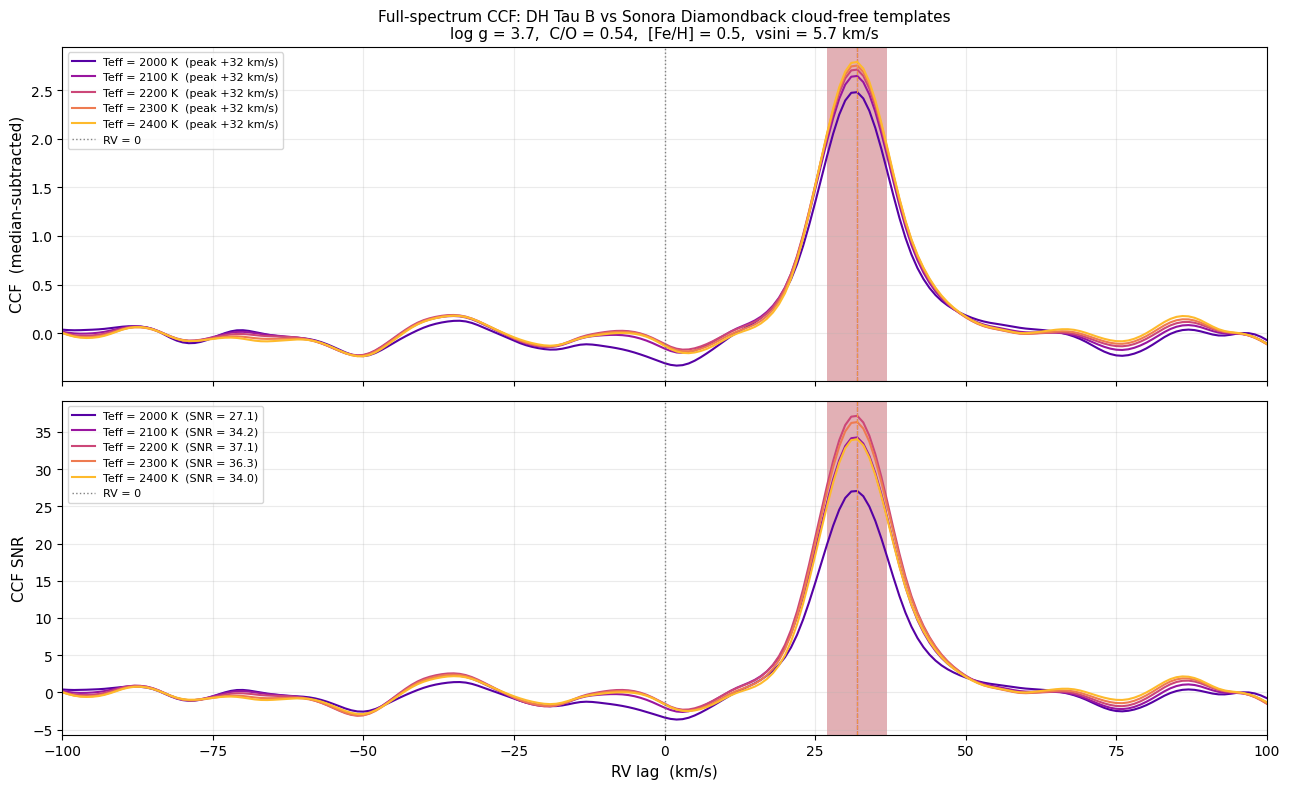

Figure saved to /data2/peng/2022-12-31/rv_prior_ccf_sonora_templates.png


In [6]:
# ============================================================
# Overlapping CCF plot — all Teff templates in one figure
# ============================================================

colors       = plt.cm.plasma(np.linspace(0.15, 0.85, len(teff_grid)))
peak_hw      = 5   # half-width [km/s] of shaded peak region

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

for i, teff in enumerate(teff_grid):
    r     = results[teff]
    c     = colors[i]
    label = f'Teff = {teff} K  (peak {r["peak_rv"]:+.0f} km/s)'

    # --- CCF panel ---
    axes[0].plot(RVlag, r['ccf'], color=c, linewidth=1.5, label=label)
    axes[0].axvspan(r['peak_rv'] - peak_hw, r['peak_rv'] + peak_hw,
                    alpha=0.12, color=c, lw=0)
    axes[0].axvline(r['peak_rv'], color=c, linestyle='--', linewidth=0.8, alpha=0.6)

    # --- SNR panel ---
    snr_label = f'Teff = {teff} K  (SNR = {r["peak_snr"]:.1f})'
    axes[1].plot(RVlag, r['snr'], color=c, linewidth=1.5, label=snr_label)
    axes[1].axvspan(r['peak_rv'] - peak_hw, r['peak_rv'] + peak_hw,
                    alpha=0.12, color=c, lw=0)
    axes[1].axvline(r['peak_rv'], color=c, linestyle='--', linewidth=0.8, alpha=0.6)

# Common decorations
for ax in axes:
    ax.axvline(0, color='gray', linestyle=':', linewidth=1.0, label='RV = 0')
    ax.grid(True, alpha=0.25)
    ax.set_xlim(RVlag[0], RVlag[-1])

axes[0].set_ylabel('CCF  (median-subtracted)', fontsize=11)
axes[0].set_title(
    'Full-spectrum CCF: DH Tau B vs Sonora Diamondback cloud-free templates\n'
    'log g = 3.7,  C/O = 0.54,  [Fe/H] = 0.5,  vsini = 5.7 km/s',
    fontsize=11
)
axes[0].legend(fontsize=8, loc='upper left')

axes[1].set_xlabel('RV lag  (km/s)', fontsize=11)
axes[1].set_ylabel('CCF SNR', fontsize=11)
axes[1].legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.savefig(f'{workpath}/{night}/rv_prior_ccf_sonora_templates.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved to {workpath}/{night}/rv_prior_ccf_sonora_templates.png')

In [7]:
# ---- RV Prior Summary ----
print('=' * 52)
print(f'  {"Teff (K)":>10}  {"Peak RV (km/s)":>16}  {"Peak SNR":>10}')
print('-' * 52)
for teff in teff_grid:
    r = results[teff]
    print(f'  {teff:>10}  {r["peak_rv"]:>+16.1f}  {r["peak_snr"]:>10.2f}')
print('=' * 52)

# Best-SNR template
best_teff = max(results, key=lambda t: results[t]['peak_snr'])
best_rv   = results[best_teff]['peak_rv']
print(f'\nBest template : Teff = {best_teff} K')
print(f'Suggested RV prior : μ = {best_rv:.1f} km/s,  σ ~ 5 km/s')

    Teff (K)    Peak RV (km/s)    Peak SNR
----------------------------------------------------
        2000             +32.0       27.06
        2100             +32.0       34.25
        2200             +32.0       37.15
        2300             +32.0       36.31
        2400             +32.0       34.01

Best template : Teff = 2200 K
Suggested RV prior : μ = 32.0 km/s,  σ ~ 5 km/s
